In [1]:
%cd "C:\Users\Lenovo\Desktop\github projects\ai-meeting-notes-analyzer-langgraph"

C:\Users\Lenovo\Desktop\github projects\ai-meeting-notes-analyzer-langgraph


# Shared State 

# Testing Shared State

In [20]:
from src.graph.meeting_state import MeetingState

In [23]:
state:MeetingState={"retriever":object(),
                    "topics":None,
                    "summary":None,
                    "action_items":None,
                    "priorities":None}
state

{'retriever': <object at 0x20effd019e0>,
 'topics': None,
 'summary': None,
 'action_items': None,
 'priorities': None}

# Creating Nodes 

# Testing Graph Node

# Build LangGraph Workflow

In [56]:
%%writefile src/graph/workflow.py

import sys 

from langgraph.graph import END,START,StateGraph
from src.graph.graph_nodes import GraphNodes
from src.graph.meeting_state import MeetingState
from src.utils.exception import ProjectException
from src.utils.logger import get_logger

logger = get_logger(__name__)

class MeetingWorkflow:

    @staticmethod
    def build():

        try:
            workflow=StateGraph(MeetingState)
            workflow.add_node("topic",GraphNodes.topic_node)
            workflow.add_node("summary",GraphNodes.summary_node)
            workflow.add_node("action",GraphNodes.action_node)
            workflow.add_node("priority", GraphNodes.priority_node)

            workflow.add_edge(START,"topic")
            workflow.add_edge("topic","summary")
            workflow.add_edge("summary","action")
            workflow.add_edge("action","priority")
            workflow.add_edge("priority",END)

            app=workflow.compile()

            logger.info("meeting workflow compiled successfully")

            return app

        except Exception as error:
            logger.error(str(error))
            raise ProjectException(str(error), sys)

Overwriting src/graph/workflow.py


# test workflow 

In [57]:
%%writefile tests/test_workflow.py

from pathlib import Path

from src.graph.meeting_state import MeetingState
from src.graph.workflow import MeetingWorkflow

from src.data_ingestion.loader import TranscriptLoader
from src.preprocessing.cleaner import TranscriptCleaner
from src.preprocessing.chunker import TranscriptChunker
from src.vector_store.embedding_model import EmbeddingModel
from src.vector_store.faiss_index import FAISSIndexManager
from src.vector_store.retriever import TranscriptRetriever


RAW_PATH = Path("data/raw/Meeting_Transcript.txt")


def build_state() -> MeetingState:

    document = TranscriptLoader.load_document(str(RAW_PATH))
    clean_document = TranscriptCleaner.clean(document)
    nodes = TranscriptChunker.create_nodes(clean_document)

    embedding_model = EmbeddingModel.load_model()

    vector_index = FAISSIndexManager.create_index(
        nodes=nodes,
        embedding_model=embedding_model,
    )

    retriever = TranscriptRetriever.create_retriever(vector_index)

    return {
        "retriever": retriever,
        "topics": None,
        "summary": None,
        "action_items": None,
        "priorities": None,
    }


def test_workflow_builds():
    app = MeetingWorkflow.build()

    assert app is not None


def test_workflow_runs():
    app = MeetingWorkflow.build()

    state = build_state()

    result = app.invoke(state)

    assert result["topics"] is not None
    assert result["summary"] is not None
    assert result["action_items"] is not None
    assert result["priorities"] is not None

Overwriting tests/test_workflow.py


In [58]:
import sys

!{sys.executable} -m pytest tests/test_workflow.py

============================= test session starts =============================
platform win32 -- Python 3.11.16, pytest-9.1.1, pluggy-1.6.0
rootdir: C:\Users\Lenovo\Desktop\github projects\ai-meeting-notes-analyzer-langgraph
configfile: pytest.ini
plugins: anyio-4.12.1, langsmith-0.12.2
collected 2 items

tests\test_workflow.py ..                                                [100%]

======================== 2 passed in 311.13s (0:05:11) ========================


2026-09-10 17:07:53 | INFO | src.graph.workflow | meeting workflow compiled successfully


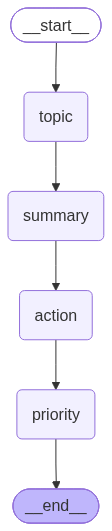

In [59]:
from src.graph.workflow import MeetingWorkflow
workflow = MeetingWorkflow.build()

workflow

In [60]:
result = workflow.invoke(state)

2026-09-10 17:08:17 | INFO | src.llm.llm | Loaded LLM: Qwen2.5-3B-Instruct.gguf
2026-09-10 17:08:17 | INFO | src.agents.topic_agent | Topic Agent executed successfully.
2026-09-10 17:09:07 | INFO | src.graph.graph_nodes | Topic node Completed
2026-09-10 17:09:10 | INFO | src.llm.llm | Loaded LLM: Qwen2.5-3B-Instruct.gguf
2026-09-10 17:09:10 | INFO | src.agents.summary_agent | Summary Agent executed successfully.
2026-09-10 17:10:18 | INFO | src.graph.graph_nodes | Summary node completed.
2026-09-10 17:10:21 | INFO | src.llm.llm | Loaded LLM: Qwen2.5-3B-Instruct.gguf
2026-09-10 17:10:21 | INFO | src.agents.action_agent | Action Agent executed successfully.
2026-09-10 17:11:35 | INFO | src.graph.graph_nodes | Action node completed.
2026-09-10 17:11:38 | INFO | src.llm.llm | Loaded LLM: Qwen2.5-3B-Instruct.gguf
2026-09-10 17:11:38 | INFO | src.agents.priority_agent | Priority Agent executed successfully.
2026-09-10 17:13:06 | INFO | src.graph.graph_nodes | Priority node completed.


In [61]:
result.keys()

dict_keys(['retriever', 'topics', 'summary', 'action_items', 'priorities'])